In [ ]:
# Imports required

import pandas as pd
from sklearn import tree, metrics, externals
from sklearn.model_selection import train_test_split
from sklearn

In [3]:
music_data_df = pd.read_csv("age-gender-23.csv")

In [9]:
#cleaning data
#music_data_df.drop_duplicates()
#music_data_df.fillna("--")
#music_data_df.info()
music_data_df.tail()

,Age,Gender,Genre
18,43,Male,Rock
19,45,Female,Jazz
20,47,Male,Classical
21,48,Female,Acoustic
22,50,Male,Country


In [11]:
# Extract - features
X = music_data_df.drop(columns=['Genre'])
X.head()

,Age,Gender
0,18,Male
1,18,Female
2,20,Male
3,21,Female
4,23,Male


In [14]:
X["Gender"] = X["Gender"].map({
    "Male": 1,
    "Female": 0,
    "Other": 2
})
X.head()

,Age,Gender
0,18,1
1,18,0
2,20,1
3,21,0
4,23,1


In [18]:
# Extract - output classifications
y = music_data_df['Genre']
y

0         HipHop
1            Pop
2           Rock
3          Dance
4           Jazz
5      Classical
6       Acoustic
7        Country
8     Electronic
9            R&B
10         Metal
11         Indie
12          Folk
13        Reggae
14         Blues
15          Soul
16        HipHop
17           Pop
18          Rock
19          Jazz
20     Classical
21      Acoustic
22       Country
Name: Genre, dtype: str

In [16]:
model = tree.DecisionTreeClassifier()

In [19]:
model.fit(X, y) # X = features, y = output classifications

e:\work\internship\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
predictions = model.predict([[36, 1], [36, 0]])
predictions

e:\work\internship\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Blues', 'Reggae'], dtype=object)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [41]:
m1 = tree.DecisionTreeClassifier()

In [43]:
m1.fit(X_train, y_train)
pred1 = m1.predict(X_test)
pred1

array(['Acoustic', 'HipHop', 'Dance', 'Indie', 'Indie', 'Indie', 'HipHop',
       'Rock', 'Dance', 'HipHop', 'Dance', 'Acoustic'], dtype=object)

In [ ]:
score = metrics.accuracy_score(y_test, pred1)
score # 85% - 100%

0.0

[Text(0.425, 0.9615384615384616, 'x[0] <= 49.0\ngini = 0.93\nsamples = 23\nvalue = [2, 1, 2, 2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1\n2, 1]'),
 Text(0.375, 0.8846153846153846, 'x[1] <= 0.5\ngini = 0.93\nsamples = 22\nvalue = [2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1\n2, 1]'),
 Text(0.4, 0.9230769230769231, 'True  '),
 Text(0.2, 0.8076923076923077, 'x[0] <= 43.0\ngini = 0.893\nsamples = 11\nvalue = [1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 2, 1, 1\n0, 1]'),
 Text(0.1, 0.7307692307692307, 'x[0] <= 19.5\ngini = 0.864\nsamples = 9\nvalue = [0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 2, 1, 1\n0, 1]'),
 Text(0.05, 0.6538461538461539, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0\n0, 0]'),
 Text(0.15, 0.6538461538461539, 'x[0] <= 22.0\ngini = 0.875\nsamples = 8\nvalue = [0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1\n0, 1]'),
 Text(0.1, 0.5769230769230769, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0\n0, 0]'),
 Text(0.2, 0.5769230769230769, 'x[0] <= 24.5\ngini = 

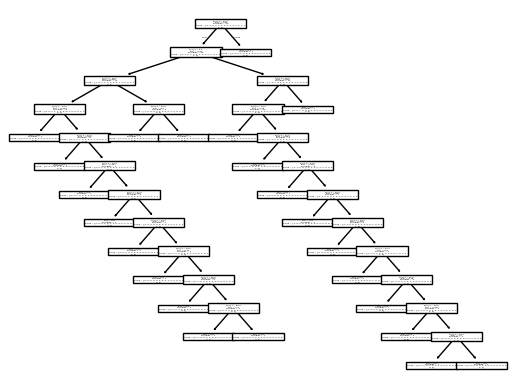

In [46]:
tree.plot_tree(model)